# AlexNet: Arquitectura y Aplicaciones con PyTorch

Este notebook explora la arquitectura AlexNet, su historia, implementación desde cero con PyTorch y diversas aplicaciones prácticas incluyendo transfer learning, visualización de características y comparación con arquitecturas más simples.

---
## Sección 1: Introducción Teórica

### 1.1 Historia y Contexto: AlexNet y la Competición ImageNet LSVRC-2012

En 2012, Alex Krizhevsky, Ilya Sutskever y Geoffrey E. Hinton presentaron una red neuronal convolucional profunda que revolucionó el campo de la visión por computadora. Su trabajo, titulado **"ImageNet Classification with Deep Convolutional Neural Networks"**, fue publicado en la conferencia NeurIPS 2012 y marcó un antes y un después en la historia del aprendizaje profundo.

La competición **ImageNet Large Scale Visual Recognition Challenge (ILSVRC)** de 2012 consistía en clasificar imágenes en 1000 categorías distintas, utilizando el conjunto de datos ImageNet que contiene más de 1.2 millones de imágenes de entrenamiento, 50,000 de validación y 150,000 de prueba.

AlexNet logró una tasa de error top-5 del **15.3%**, reduciendo en más de 10 puntos porcentuales el mejor resultado anterior (26.2%), que utilizaba métodos de visión computacional clásicos basados en características manuales (SIFT, Fisher Vectors, etc.). Este resultado fue tan sorprendente que la comunidad científica tardó en creer los resultados, pero marcó el inicio de la era del deep learning moderno.

---

### 1.2 Impacto de AlexNet en el Campo del Deep Learning

El impacto de AlexNet fue inmediato y duradero:

- **Demostró la viabilidad de las redes profundas**: Mostró que las redes neuronales profundas podían superar drásticamente a los métodos clásicos en tareas de visión.
- **Popularizó el uso de GPUs**: Fue una de las primeras implementaciones que aprovechó el poder de las GPUs (específicamente dos NVIDIA GTX 580 de 3GB) para acelerar el entrenamiento de redes profundas.
- **Introdujo técnicas que hoy son estándar**: ReLU, Dropout, data augmentation y overlapping pooling se convirtieron en herramientas fundamentales del deep learning.
- **Catalizó la investigación**: Inspiró una nueva generación de arquitecturas (VGG, GoogLeNet, ResNet, etc.) y el desarrollo de frameworks de deep learning como TensorFlow y PyTorch.
- **Transformó la industria**: Impulsó aplicaciones en reconocimiento de imágenes, diagnóstico médico, vehículos autónomos y muchos otros campos.

Desde 2012, prácticamente todos los sistemas de reconocimiento visual de alto rendimiento se basan en redes neuronales convolucionales profundas.

---

### 1.3 Descripción Detallada de la Arquitectura

AlexNet está compuesta por **8 capas con parámetros entrenables**: 5 capas convolucionales y 3 capas completamente conectadas (fully connected). En total, la red tiene aproximadamente **60 millones de parámetros**.

#### 1.3.1 ReLU como Función de Activación

Una de las contribuciones más importantes de AlexNet fue el uso de la función de activación **Rectified Linear Unit (ReLU)**:

$$f(x) = \max(0, x)$$

Ventajas sobre la sigmoide y la tangente hiperbólica:
- **No satura**: No sufre del problema del gradiente desvaneciente en valores positivos grandes.
- **Computacionalmente eficiente**: Solo requiere una comparación con cero.
- **Convergencia más rápida**: Los autores reportaron que con ReLU el entrenamiento fue 6 veces más rápido que con tanh.
- **Promueve la dispersión (sparsity)**: Produce activaciones cero para valores negativos, lo que puede mejorar la representación.

#### 1.3.2 Local Response Normalization (LRN)

AlexNet introdujo la **Normalización de Respuesta Local (LRN)**, inspirada en el concepto de inhibición lateral observado en las neuronas biológicas. La fórmula es:

$$b^i_{x,y} = a^i_{x,y} \left( k + \alpha \sum_{j=\max(0, i-n/2)}^{\min(N-1, i+n/2)} (a^j_{x,y})^2 \right)^{-\beta}$$

Donde $a^i_{x,y}$ es la activación de la neurona en la posición $(x,y)$ del canal $i$, $N$ es el número total de canales, y $n$, $k$, $\alpha$, $\beta$ son hiperparámetros. En el paper original: $k=2$, $n=5$, $\alpha=10^{-4}$, $\beta=0.75$.

**Nota**: Las arquitecturas posteriores (como VGG) demostraron que LRN no mejora significativamente el rendimiento y fue abandonada en favor de la Batch Normalization.

#### 1.3.3 Overlapping Max Pooling

A diferencia del pooling tradicional donde el tamaño del kernel y el stride son iguales (sin solapamiento), AlexNet utilizó **max pooling con solapamiento**: kernel de tamaño 3×3 con stride 2. Esto significa que las regiones de pooling se solapan, lo que según los autores reduce ligeramente el error y hace que el modelo sea más difícil de sobreajustar.

#### 1.3.4 Dropout como Técnica de Regularización

AlexNet popularizó el uso del **Dropout** en las capas fully connected. Durante el entrenamiento, con probabilidad $p=0.5$, cada neurona se "apaga" (su salida se establece a cero), lo que:
- Previene el co-adaptamiento de neuronas.
- Actúa como un ensemble de múltiples redes.
- Reduce significativamente el sobreajuste.

Durante la inferencia, todas las neuronas están activas pero sus salidas se escalan por $(1-p)$.

#### 1.3.5 Data Augmentation

Para reducir el sobreajuste con solo 1.2M imágenes de entrenamiento, AlexNet aplicó dos formas de **aumento de datos**:

1. **Recortes aleatorios y reflexiones horizontales**: De cada imagen de 256×256 se extraían parches aleatorios de 224×224 y sus reflexiones horizontales, generando 2048 versiones por imagen.
2. **Perturbaciones de intensidad de color**: Aplicaban PCA sobre los canales RGB del conjunto de entrenamiento y añadían múltiplos de los componentes principales con magnitudes proporcionales a los valores propios correspondientes.

#### 1.3.6 Entrenamiento en Múltiples GPUs (Contexto Histórico)

En 2012, las GPUs NVIDIA GTX 580 solo tenían 3GB de memoria, insuficiente para entrenar AlexNet en una sola GPU. Los autores dividieron la red entre **dos GPUs** en paralelo:
- Los mapas de características se distribuían entre las dos GPUs.
- Las GPUs solo se comunicaban en capas específicas.
- Esto permitió entrenar un modelo más grande y redujo el tiempo de entrenamiento a la mitad.

Este enfoque fue pionero en el entrenamiento distribuido de redes neuronales, técnica que hoy es estándar para modelos de gran escala.

---

### 1.4 Diagrama y Descripción Capa por Capa

La arquitectura original de AlexNet para ImageNet (entrada 224×224×3):

```
Entrada: 224 × 224 × 3
│
├─ Conv1: 96 filtros, 11×11, stride 4  →  55×55×96
│  └─ ReLU → LRN → MaxPool (3×3, stride 2)  →  27×27×96
│
├─ Conv2: 256 filtros, 5×5, padding 2  →  27×27×256
│  └─ ReLU → LRN → MaxPool (3×3, stride 2)  →  13×13×256
│
├─ Conv3: 384 filtros, 3×3, padding 1  →  13×13×384
│  └─ ReLU
│
├─ Conv4: 384 filtros, 3×3, padding 1  →  13×13×384
│  └─ ReLU
│
├─ Conv5: 256 filtros, 3×3, padding 1  →  13×13×256
│  └─ ReLU → MaxPool (3×3, stride 2)  →  6×6×256
│
├─ Flatten  →  9216
│
├─ FC6: 4096 neuronas  →  Dropout(0.5) → ReLU
│
├─ FC7: 4096 neuronas  →  Dropout(0.5) → ReLU
│
└─ FC8: 1000 neuronas  →  Softmax
```

**Parámetros por capa (aproximado)**:
| Capa   | Parámetros |
|--------|------------|
| Conv1  | 34,944     |
| Conv2  | 614,400    |
| Conv3  | 885,120    |
| Conv4  | 1,327,488  |
| Conv5  | 884,992    |
| FC6    | 37,748,736 |
| FC7    | 16,777,216 |
| FC8    | 4,097,000  |
| **Total** | **~62.3M** |

---

### 1.5 Innovaciones Clave de AlexNet

En resumen, AlexNet introdujo o popularizó las siguientes innovaciones:

1. **Uso de ReLU**: Primera demostración a gran escala de la superioridad de ReLU sobre sigmoide/tanh.
2. **Entrenamiento en GPU**: Demostró que las GPUs eran esenciales para entrenar redes profundas en tiempos razonables.
3. **Dropout**: Técnica de regularización que se convirtió en estándar para prevenir el sobreajuste.
4. **Data augmentation**: Estrategia sistemática para aumentar artificialmente el tamaño del conjunto de datos.
5. **Overlapping pooling**: Mejora sutil pero efectiva sobre el pooling tradicional.
6. **Arquitectura profunda**: Demostró que la profundidad (más capas) es crucial para el rendimiento.
7. **Entrenamiento paralelo en múltiples GPUs**: Pionero en computación distribuida para deep learning.

---
## Sección 2: Implementación de AlexNet con PyTorch

### 2.1 Importaciones y Configuración Inicial

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import time

# Semillas para reproducibilidad
torch.manual_seed(1)
np.random.seed(1)

# Configurar dispositivo (GPU si está disponible, de lo contrario CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: cpu


### 2.2 Definición de la Clase AlexNet Adaptada para CIFAR-10

La arquitectura original de AlexNet fue diseñada para imágenes de 224×224. Para CIFAR-10 (32×32), adaptamos los hiperparámetros: usamos kernels más pequeños, strides de 1 y un `AdaptiveAvgPool2d` al final para obtener un tamaño fijo independientemente de la resolución de entrada.

In [ ]:
class AlexNet(nn.Module):
    """AlexNet adaptada para imágenes pequeñas (32x32) como CIFAR-10."""
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()
        # Bloque de capas convolucionales (extracción de características)
        self.features = nn.Sequential(
            # Capa Conv1: 64 filtros 3x3, stride 1, padding 1
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # LRN incluida por fidelidad histórica al paper original;
            # en arquitecturas modernas se sustituye por BatchNorm2d
            nn.LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=2, stride=2),           # 32x32 -> 16x16

            # Capa Conv2: 192 filtros 3x3
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=2, stride=2),           # 16x16 -> 8x8

            # Capa Conv3: 384 filtros 3x3
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Capa Conv4: 256 filtros 3x3
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Capa Conv5: 256 filtros 3x3
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),           # 8x8 -> 4x4
        )
        # Pooling adaptativo para obtener salida de tamaño fijo 2x2
        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))

        # Bloque de capas completamente conectadas (clasificador)
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 2 * 2, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)       # Extraer características con conv layers
        x = self.avgpool(x)        # Pooling adaptativo
        x = torch.flatten(x, 1)   # Aplanar para las capas FC
        x = self.classifier(x)    # Clasificar
        return x


def count_parameters(model):
    """Cuenta el número total de parámetros entrenables de un modelo."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Instanciar el modelo y mostrar su arquitectura
alexnet = AlexNet(num_classes=10).to(device)
print(alexnet)
print(f'\nNúmero total de parámetros entrenables: {count_parameters(alexnet):,}')

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(2, 2))
  (classifie

### 2.3 Funciones Auxiliares de Entrenamiento y Evaluación

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Entrena el modelo durante una época y devuelve pérdida y exactitud medias."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()          # Reiniciar gradientes
        outputs = model(inputs)        # Paso hacia adelante
        loss = criterion(outputs, labels)
        loss.backward()                # Paso hacia atrás
        optimizer.step()               # Actualizar pesos

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    """Evalúa el modelo en un conjunto de datos y devuelve pérdida y exactitud."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs, device, scheduler=None):
    """Ciclo de entrenamiento completo con seguimiento de métricas."""
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Época [{epoch+1:2d}/{num_epochs}] '
              f'| Pérdida Entren: {train_loss:.4f} | Exactitud Entren: {train_acc:.2f}% '
              f'| Pérdida Val: {val_loss:.4f} | Exactitud Val: {val_acc:.2f}%')

    elapsed = time.time() - start_time
    print(f'\nTiempo total de entrenamiento: {elapsed:.1f}s')
    return history, elapsed


def plot_training_curves(history, title='Curvas de Entrenamiento'):
    """Grafica las curvas de pérdida y exactitud de entrenamiento y validación."""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Curva de pérdida
    ax1.plot(epochs, history['train_loss'], 'b-o', label='Entrenamiento', linewidth=2)
    ax1.plot(epochs, history['val_loss'], 'r-o', label='Validación', linewidth=2)
    ax1.set_title(f'{title}\nPérdida (Cross-Entropy)', fontsize=13)
    ax1.set_xlabel('Época', fontsize=12)
    ax1.set_ylabel('Pérdida', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # Curva de exactitud
    ax2.plot(epochs, history['train_acc'], 'b-o', label='Entrenamiento', linewidth=2)
    ax2.plot(epochs, history['val_acc'], 'r-o', label='Validación', linewidth=2)
    ax2.set_title(f'{title}\nExactitud (%)', fontsize=13)
    ax2.set_xlabel('Época', fontsize=12)
    ax2.set_ylabel('Exactitud (%)', fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


print('Funciones auxiliares definidas correctamente.')

Funciones auxiliares definidas correctamente.


---
## Sección 3: Ejemplo 1 — AlexNet con CIFAR-10

En este ejemplo entrenamos nuestra implementación de AlexNet en el conjunto de datos CIFAR-10, que contiene 60,000 imágenes de 32×32 píxeles en 10 clases. Para agilizar la demostración, usamos un subconjunto de los datos y entrenamos durante 5 épocas.

### 3.1 Carga y Preparación de los Datos

In [ ]:
# Transformaciones con data augmentation para entrenamiento
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),              # Volteo horizontal aleatorio
    transforms.RandomCrop(32, padding=4),           # Recorte aleatorio con padding
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), # Media de cada canal RGB en CIFAR-10
                         (0.2023, 0.1994, 0.2010)), # Desviación estándar de cada canal
])

# Transformación sin augmentation para prueba
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

# Descargar CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

# Usar subconjunto para demo (más rápido)
train_subset = Subset(train_dataset, range(5000))
val_subset   = Subset(train_dataset, range(5000, 6000))
test_subset  = Subset(test_dataset,  range(1000))

# DataLoaders
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_subset,   batch_size=64, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_subset,  batch_size=64, shuffle=False, num_workers=0)

# Nombres de las clases de CIFAR-10
classes = ['avión', 'automóvil', 'pájaro', 'gato', 'venado',
           'perro', 'rana', 'caballo', 'barco', 'camión']

print(f'Tamaño del subconjunto de entrenamiento : {len(train_subset)}')
print(f'Tamaño del subconjunto de validación   : {len(val_subset)}')
print(f'Tamaño del subconjunto de prueba       : {len(test_subset)}')

100%|██████████| 170M/170M [00:12<00:00, 13.3MB/s]


Tamaño del subconjunto de entrenamiento : 5000
Tamaño del subconjunto de validación   : 1000
Tamaño del subconjunto de prueba       : 1000


### 3.2 Visualización de Algunas Imágenes del Dataset

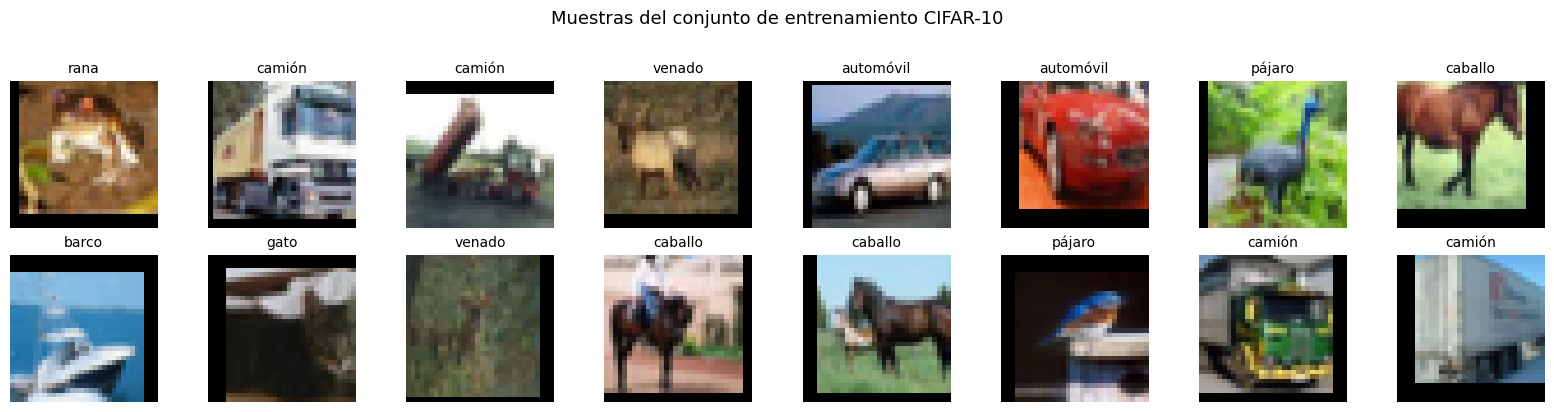

In [ ]:
# Función para desnormalizar imágenes y visualizarlas
def imshow(img, ax, title=''):
    """Muestra una imagen tensor desnormalizada en un eje de matplotlib."""
    mean = np.array([0.4914, 0.4822, 0.4465])
    std  = np.array([0.2023, 0.1994, 0.2010])
    img = img.numpy().transpose((1, 2, 0))  # (C,H,W) -> (H,W,C)
    img = std * img + mean                   # Desnormalizar
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

# Mostrar las primeras 16 imágenes del subconjunto de entrenamiento
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes = axes.flatten()

for i in range(16):
    img, label = train_subset[i]
    imshow(img, axes[i], title=classes[label])

fig.suptitle('Muestras del conjunto de entrenamiento CIFAR-10', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Entrenamiento de AlexNet en CIFAR-10

In [ ]:
# Instanciar modelo, función de pérdida y optimizador
model_alexnet = AlexNet(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_alexnet.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

# Entrenar durante 5 épocas (demo)
NUM_EPOCHS = 5
print('=== Entrenamiento de AlexNet en CIFAR-10 (subconjunto de demostración) ===')
history_alexnet, time_alexnet = train_model(
    model_alexnet, train_loader, val_loader,
    criterion, optimizer, NUM_EPOCHS, device, scheduler
)

=== Entrenamiento de AlexNet en CIFAR-10 (subconjunto de demostración) ===
Época [ 1/5] | Pérdida Entren: 2.2029 | Exactitud Entren: 15.70% | Pérdida Val: 2.0511 | Exactitud Val: 23.70%
Época [ 2/5] | Pérdida Entren: 2.0122 | Exactitud Entren: 22.32% | Pérdida Val: 1.9896 | Exactitud Val: 22.70%
Época [ 3/5] | Pérdida Entren: 1.9462 | Exactitud Entren: 24.30% | Pérdida Val: 1.8965 | Exactitud Val: 25.10%
Época [ 4/5] | Pérdida Entren: 1.8670 | Exactitud Entren: 26.88% | Pérdida Val: 1.8887 | Exactitud Val: 26.00%
Época [ 5/5] | Pérdida Entren: 1.8133 | Exactitud Entren: 28.30% | Pérdida Val: 1.8089 | Exactitud Val: 30.90%

Tiempo total de entrenamiento: 811.0s


### 3.4 Curvas de Pérdida y Exactitud

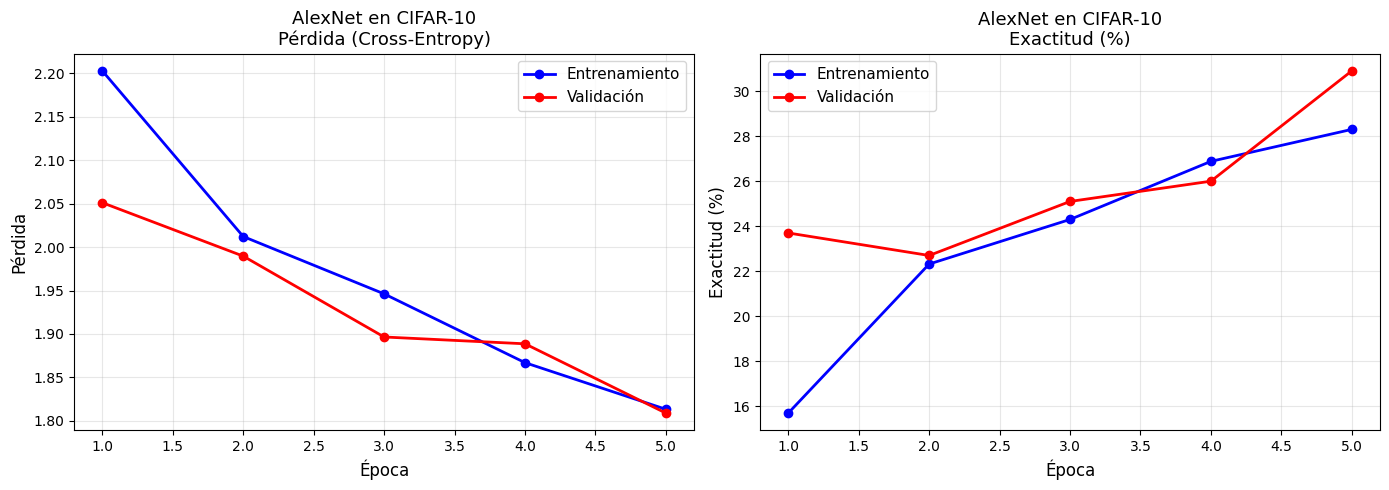

In [ ]:
# Graficar curvas de entrenamiento
plot_training_curves(history_alexnet, title='AlexNet en CIFAR-10')

### 3.5 Evaluación en el Conjunto de Prueba y Matriz de Confusión

Exactitud en prueba (AlexNet): 30.90%


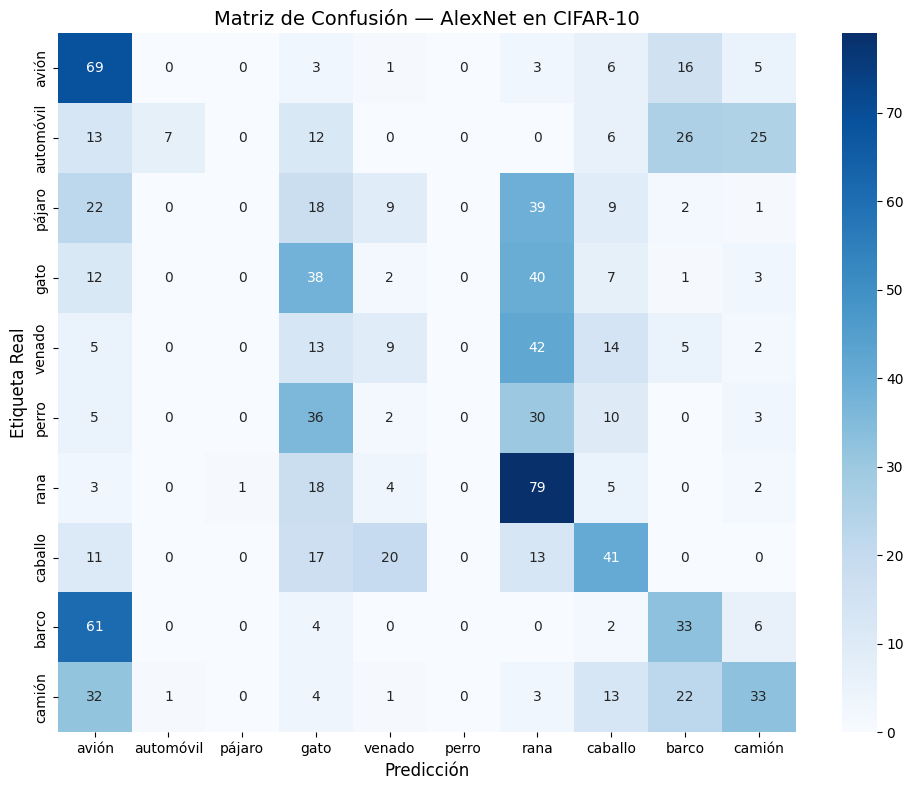

In [ ]:
# Obtener predicciones en el conjunto de prueba
model_alexnet.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_alexnet(inputs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_accuracy = 100.0 * (all_preds == all_labels).mean()
print(f'Exactitud en prueba (AlexNet): {test_accuracy:.2f}%')

# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title('Matriz de Confusión — AlexNet en CIFAR-10', fontsize=14)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Etiqueta Real', fontsize=12)
plt.tight_layout()
plt.show()

### 3.6 Visualización de Predicciones Correctas e Incorrectas

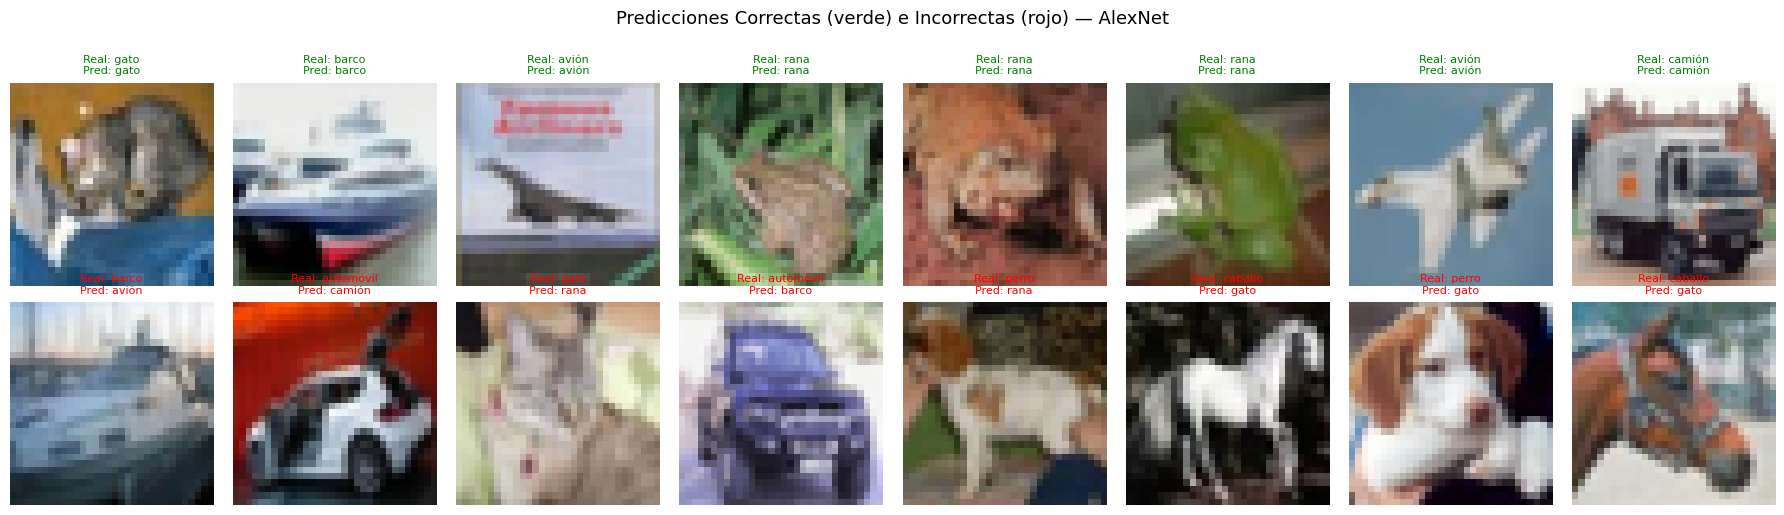

In [ ]:
# Seleccionar predicciones correctas e incorrectas
correct_idx   = np.where(all_preds == all_labels)[0][:8]
incorrect_idx = np.where(all_preds != all_labels)[0][:8]

fig, axes = plt.subplots(2, 8, figsize=(18, 5))

for col, idx in enumerate(correct_idx):
    img, label = test_subset[idx]
    axes[0, col].set_title(
        f'Real: {classes[label]}\nPred: {classes[all_preds[idx]]}',
        color='green', fontsize=8
    )
    mean = np.array([0.4914, 0.4822, 0.4465])
    std  = np.array([0.2023, 0.1994, 0.2010])
    img_np = img.numpy().transpose(1, 2, 0)
    img_np = np.clip(std * img_np + mean, 0, 1)
    axes[0, col].imshow(img_np)
    axes[0, col].axis('off')

for col, idx in enumerate(incorrect_idx):
    img, label = test_subset[idx]
    axes[1, col].set_title(
        f'Real: {classes[label]}\nPred: {classes[all_preds[idx]]}',
        color='red', fontsize=8
    )
    img_np = img.numpy().transpose(1, 2, 0)
    img_np = np.clip(std * img_np + mean, 0, 1)
    axes[1, col].imshow(img_np)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Correctas ✓', fontsize=11, color='green', rotation=90, labelpad=10)
axes[1, 0].set_ylabel('Incorrectas ✗', fontsize=11, color='red',   rotation=90, labelpad=10)
fig.suptitle('Predicciones Correctas (verde) e Incorrectas (rojo) — AlexNet',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Sección 4: Ejemplo 2 — Transfer Learning con AlexNet Pre-entrenado

El **Transfer Learning** consiste en reutilizar un modelo entrenado en una tarea (ImageNet, 1000 clases) para resolver una tarea diferente (CIFAR-10, 10 clases). La intuición es que las capas convolucionales aprenden características visuales genéricas (bordes, texturas, formas) que son útiles para muchas tareas de visión.

### Estrategia de Fine-tuning
1. **Cargar AlexNet pre-entrenada** en ImageNet (pesos de `IMAGENET1K_V1`).
2. **Congelar las capas convolucionales** (`features`): sus pesos no se actualizarán.
3. **Reemplazar el clasificador final** por uno adaptado a 10 clases.
4. **Entrenar solo las capas FC** con una tasa de aprendizaje baja.

### 4.1 Carga del Modelo Pre-entrenado

In [ ]:
# Cargar AlexNet con pesos pre-entrenados en ImageNet
# Se usa la API actualizada con 'weights' en lugar del parámetro obsoleto 'pretrained'
alexnet_pretrained = models.alexnet(
    weights=torchvision.models.AlexNet_Weights.IMAGENET1K_V1
)

# Congelar todos los parámetros de las capas convolucionales
for param in alexnet_pretrained.features.parameters():
    param.requires_grad = False

# Reemplazar el clasificador final para adaptarlo a 10 clases de CIFAR-10
# El clasificador original de AlexNet termina en 1000 (clases de ImageNet)
alexnet_pretrained.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(256 * 6 * 6, 4096),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 512),
    nn.ReLU(inplace=True),
    nn.Linear(512, 10),   # 10 clases para CIFAR-10
)

alexnet_pretrained = alexnet_pretrained.to(device)

# Mostrar qué parámetros están congelados y cuáles son entrenables
total_params    = sum(p.numel() for p in alexnet_pretrained.parameters())
trainable_params = count_parameters(alexnet_pretrained)
frozen_params   = total_params - trainable_params

print(f'Parámetros totales         : {total_params:,}')
print(f'Parámetros congelados      : {frozen_params:,}')
print(f'Parámetros entrenables     : {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 124MB/s]


Parámetros totales         : 42,325,322
Parámetros congelados      : 2,469,696
Parámetros entrenables     : 39,855,626


### 4.2 Preparar Datos con Redimensionamiento para AlexNet Pre-entrenada

La AlexNet pre-entrenada espera imágenes de 224×224 y normalización específica de ImageNet. Redimensionamos las imágenes de CIFAR-10 (32×32) a 64×64 como compromiso entre calidad y eficiencia.

In [ ]:
# Transformaciones con normalización de ImageNet para el modelo pre-entrenado
transform_tl_train = transforms.Compose([
    transforms.Resize((64, 64)),                  # Redimensionar a 64x64
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Media de ImageNet
                         std=[0.229, 0.224, 0.225]),   # Desv. est. de ImageNet
])

transform_tl_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Recargar datasets con las nuevas transformaciones
train_dataset_tl = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transform_tl_train)
test_dataset_tl = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=transform_tl_test)

train_subset_tl = Subset(train_dataset_tl, range(5000))
val_subset_tl   = Subset(train_dataset_tl, range(5000, 6000))
test_subset_tl  = Subset(test_dataset_tl,  range(1000))

train_loader_tl = DataLoader(train_subset_tl, batch_size=64, shuffle=True,  num_workers=0)
val_loader_tl   = DataLoader(val_subset_tl,   batch_size=64, shuffle=False, num_workers=0)
test_loader_tl  = DataLoader(test_subset_tl,  batch_size=64, shuffle=False, num_workers=0)

print('DataLoaders para transfer learning creados correctamente.')

DataLoaders para transfer learning creados correctamente.


### 4.3 Entrenamiento con Transfer Learning

In [ ]:
# Solo optimizar los parámetros entrenables (capas FC)
optimizer_tl = optim.Adam(
    filter(lambda p: p.requires_grad, alexnet_pretrained.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler_tl = optim.lr_scheduler.StepLR(optimizer_tl, step_size=3, gamma=0.5)

print('=== Transfer Learning: AlexNet Pre-entrenada (solo FC entrenables) ===')
history_tl, time_tl = train_model(
    alexnet_pretrained, train_loader_tl, val_loader_tl,
    criterion, optimizer_tl, NUM_EPOCHS, device, scheduler_tl
)

# Evaluar en el conjunto de prueba
test_loss_tl, test_acc_tl = evaluate(alexnet_pretrained, test_loader_tl, criterion, device)
print(f'\nExactitud en prueba (Transfer Learning): {test_acc_tl:.2f}%')

=== Transfer Learning: AlexNet Pre-entrenada (solo FC entrenables) ===
Época [ 1/5] | Pérdida Entren: 2.4812 | Exactitud Entren: 43.32% | Pérdida Val: 1.2450 | Exactitud Val: 57.30%
Época [ 2/5] | Pérdida Entren: 1.2500 | Exactitud Entren: 55.26% | Pérdida Val: 1.2161 | Exactitud Val: 58.40%
Época [ 3/5] | Pérdida Entren: 1.1747 | Exactitud Entren: 58.82% | Pérdida Val: 1.1682 | Exactitud Val: 59.60%
Época [ 4/5] | Pérdida Entren: 1.0402 | Exactitud Entren: 63.18% | Pérdida Val: 1.0798 | Exactitud Val: 62.40%
Época [ 5/5] | Pérdida Entren: 0.9777 | Exactitud Entren: 65.36% | Pérdida Val: 1.0891 | Exactitud Val: 62.80%

Tiempo total de entrenamiento: 397.7s

Exactitud en prueba (Transfer Learning): 62.10%


### 4.4 Comparación: Entrenamiento desde Cero vs. Transfer Learning

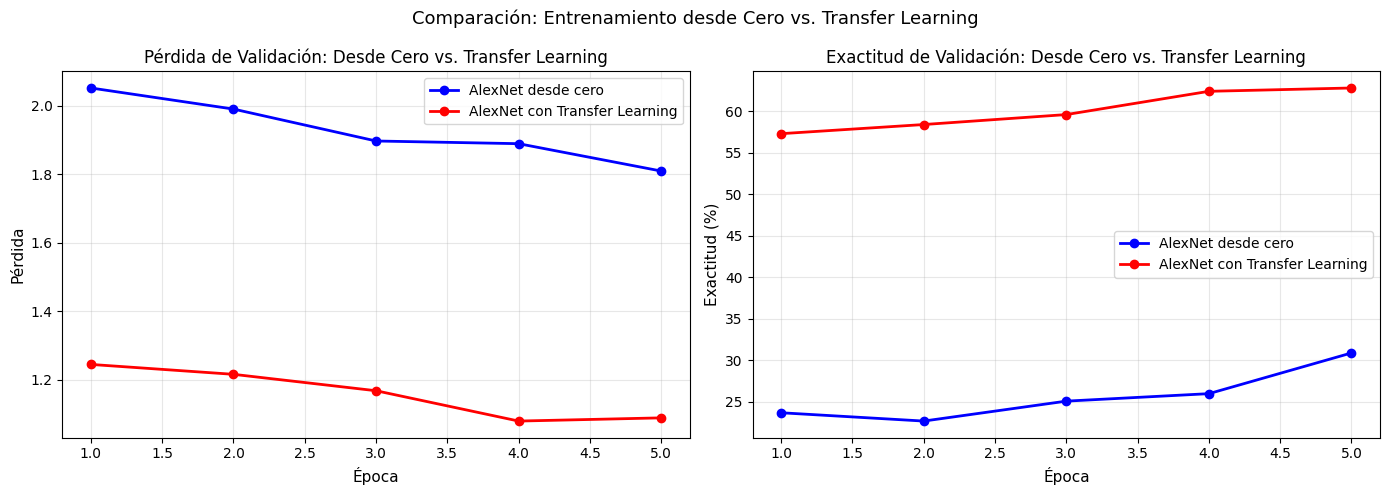


Exactitud final de validación — Desde cero     : 30.90%
Exactitud final de validación — Transfer Learning: 62.80%


In [ ]:
# Graficar curvas de ambos modelos en el mismo gráfico
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Curvas de pérdida de validación
ax1.plot(epochs, history_alexnet['val_loss'], 'b-o',
         label='AlexNet desde cero', linewidth=2)
ax1.plot(epochs, history_tl['val_loss'], 'r-o',
         label='AlexNet con Transfer Learning', linewidth=2)
ax1.set_title('Pérdida de Validación: Desde Cero vs. Transfer Learning', fontsize=12)
ax1.set_xlabel('Época', fontsize=11)
ax1.set_ylabel('Pérdida', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Curvas de exactitud de validación
ax2.plot(epochs, history_alexnet['val_acc'], 'b-o',
         label='AlexNet desde cero', linewidth=2)
ax2.plot(epochs, history_tl['val_acc'], 'r-o',
         label='AlexNet con Transfer Learning', linewidth=2)
ax2.set_title('Exactitud de Validación: Desde Cero vs. Transfer Learning', fontsize=12)
ax2.set_xlabel('Época', fontsize=11)
ax2.set_ylabel('Exactitud (%)', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Comparación: Entrenamiento desde Cero vs. Transfer Learning', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nExactitud final de validación — Desde cero     : {history_alexnet["val_acc"][-1]:.2f}%')
print(f'Exactitud final de validación — Transfer Learning: {history_tl["val_acc"][-1]:.2f}%')

---
## Sección 5: Ejemplo 3 — Visualización de Características Aprendidas

Una de las preguntas fundamentales en deep learning es: **¿qué aprende cada capa de una red convolucional?**

- **Primera capa convolucional**: Aprende detectores de características de bajo nivel: bordes en distintas orientaciones, gradientes de color, manchas.
- **Capas intermedias**: Combinan las características simples para detectar texturas, partes de objetos.
- **Capas profundas**: Aprenden representaciones semánticas de alto nivel: formas complejas, partes de objetos, patrones específicos de clases.

### 5.1 Visualización de los Filtros de la Primera Capa Convolucional

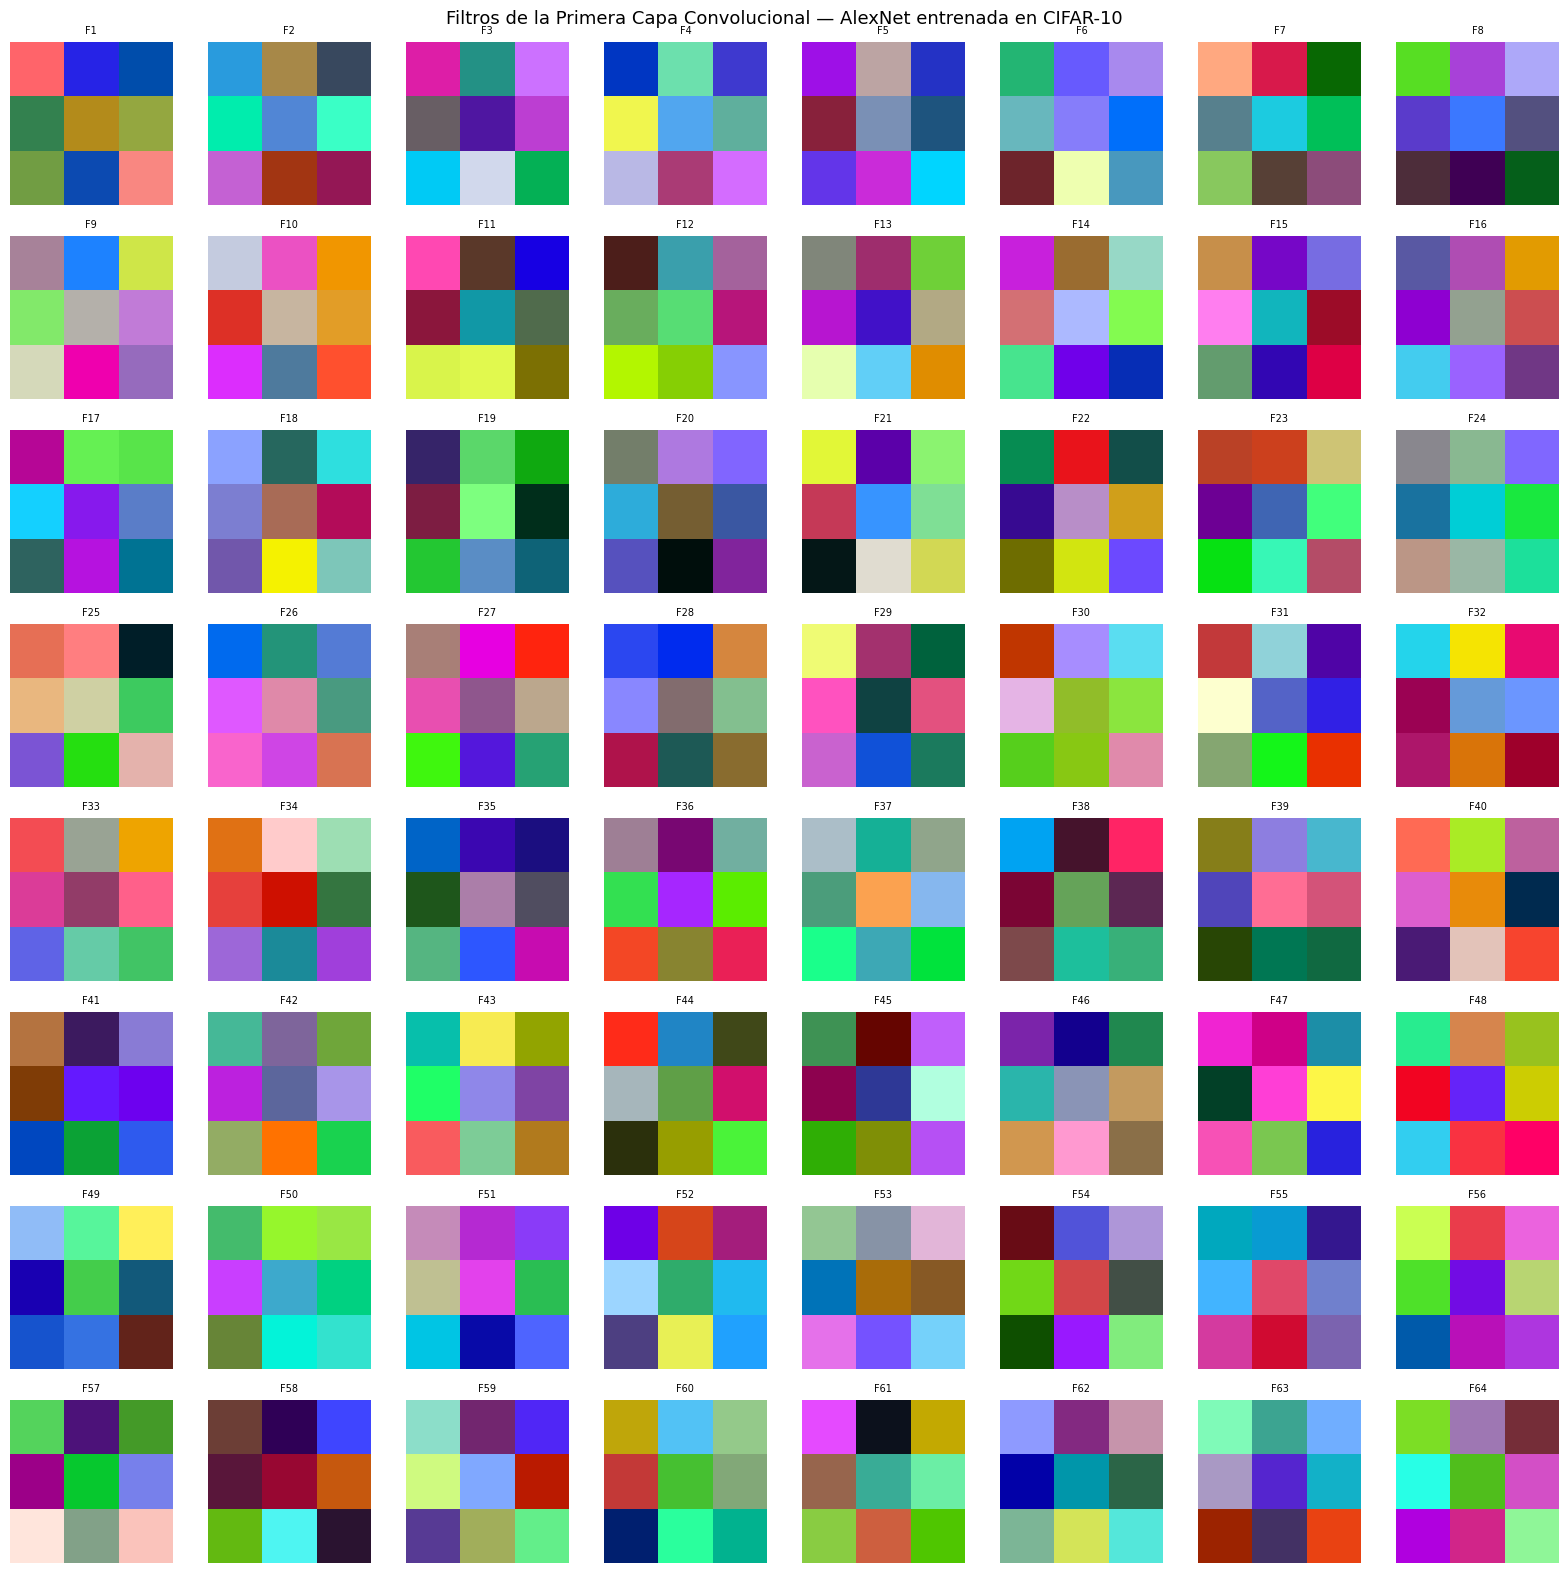

Forma de los pesos: torch.Size([64, 3, 3, 3]) (64 filtros de 3x3 con 3 canales)


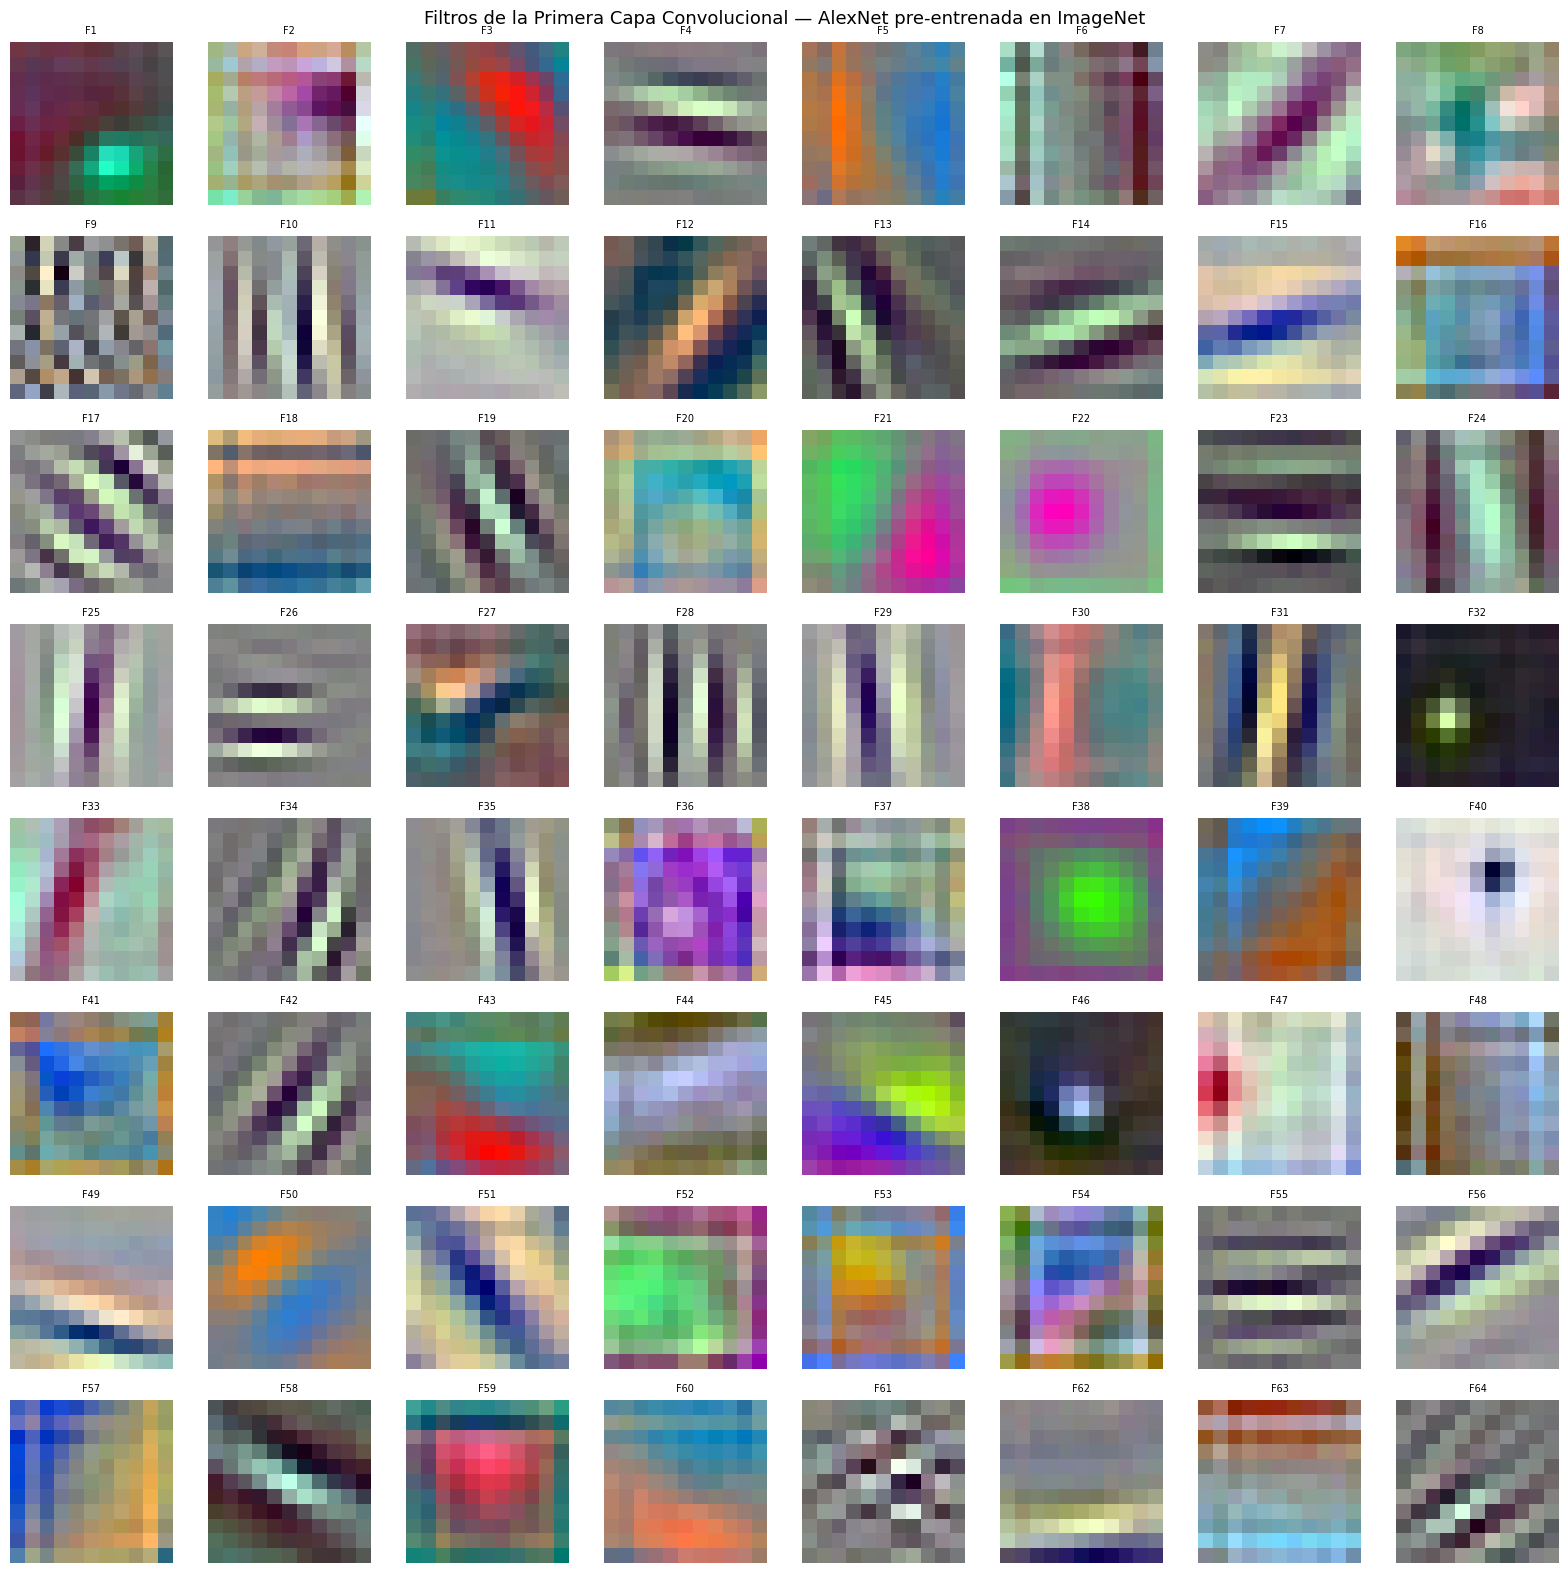

Forma de los pesos: torch.Size([64, 3, 11, 11]) (64 filtros de 11x11 con 3 canales)


In [ ]:
def visualize_filters(model, layer_name='features.0', title='Filtros de la primera capa convolucional'):
    """Visualiza los filtros (kernels) de una capa convolucional."""
    # Obtener los pesos de la primera capa convolucional
    for name, module in model.named_modules():
        if name == layer_name and isinstance(module, nn.Conv2d):
            weights = module.weight.data.cpu()
            break

    n_filters = min(weights.shape[0], 64)  # Mostrar máximo 64 filtros
    n_cols = 8
    n_rows = n_filters // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 2))
    axes = axes.flatten()

    for i in range(n_filters):
        # Normalizar cada filtro al rango [0, 1] para visualización
        filt = weights[i].permute(1, 2, 0).numpy()  # (C,H,W) -> (H,W,C)
        filt_min, filt_max = filt.min(), filt.max()
        filt = (filt - filt_min) / (filt_max - filt_min + 1e-8)
        axes[i].imshow(filt)
        axes[i].axis('off')
        axes[i].set_title(f'F{i+1}', fontsize=7)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f'Forma de los pesos: {weights.shape} '
          f'({weights.shape[0]} filtros de {weights.shape[2]}x{weights.shape[3]} con {weights.shape[1]} canales)')


# Visualizar filtros del modelo entrenado desde cero
visualize_filters(
    model_alexnet,
    layer_name='features.0',
    title='Filtros de la Primera Capa Convolucional — AlexNet entrenada en CIFAR-10'
)

# Visualizar filtros del modelo pre-entrenado en ImageNet (para comparación)
visualize_filters(
    alexnet_pretrained,
    layer_name='features.0',
    title='Filtros de la Primera Capa Convolucional — AlexNet pre-entrenada en ImageNet'
)

### 5.2 Visualización de Mapas de Activación (Feature Maps)

Los **mapas de activación** muestran qué partes de la imagen activan cada filtro. Registraremos las activaciones de cada capa convolucional para una imagen de muestra usando hooks de PyTorch.

Clase de la imagen de muestra: gato


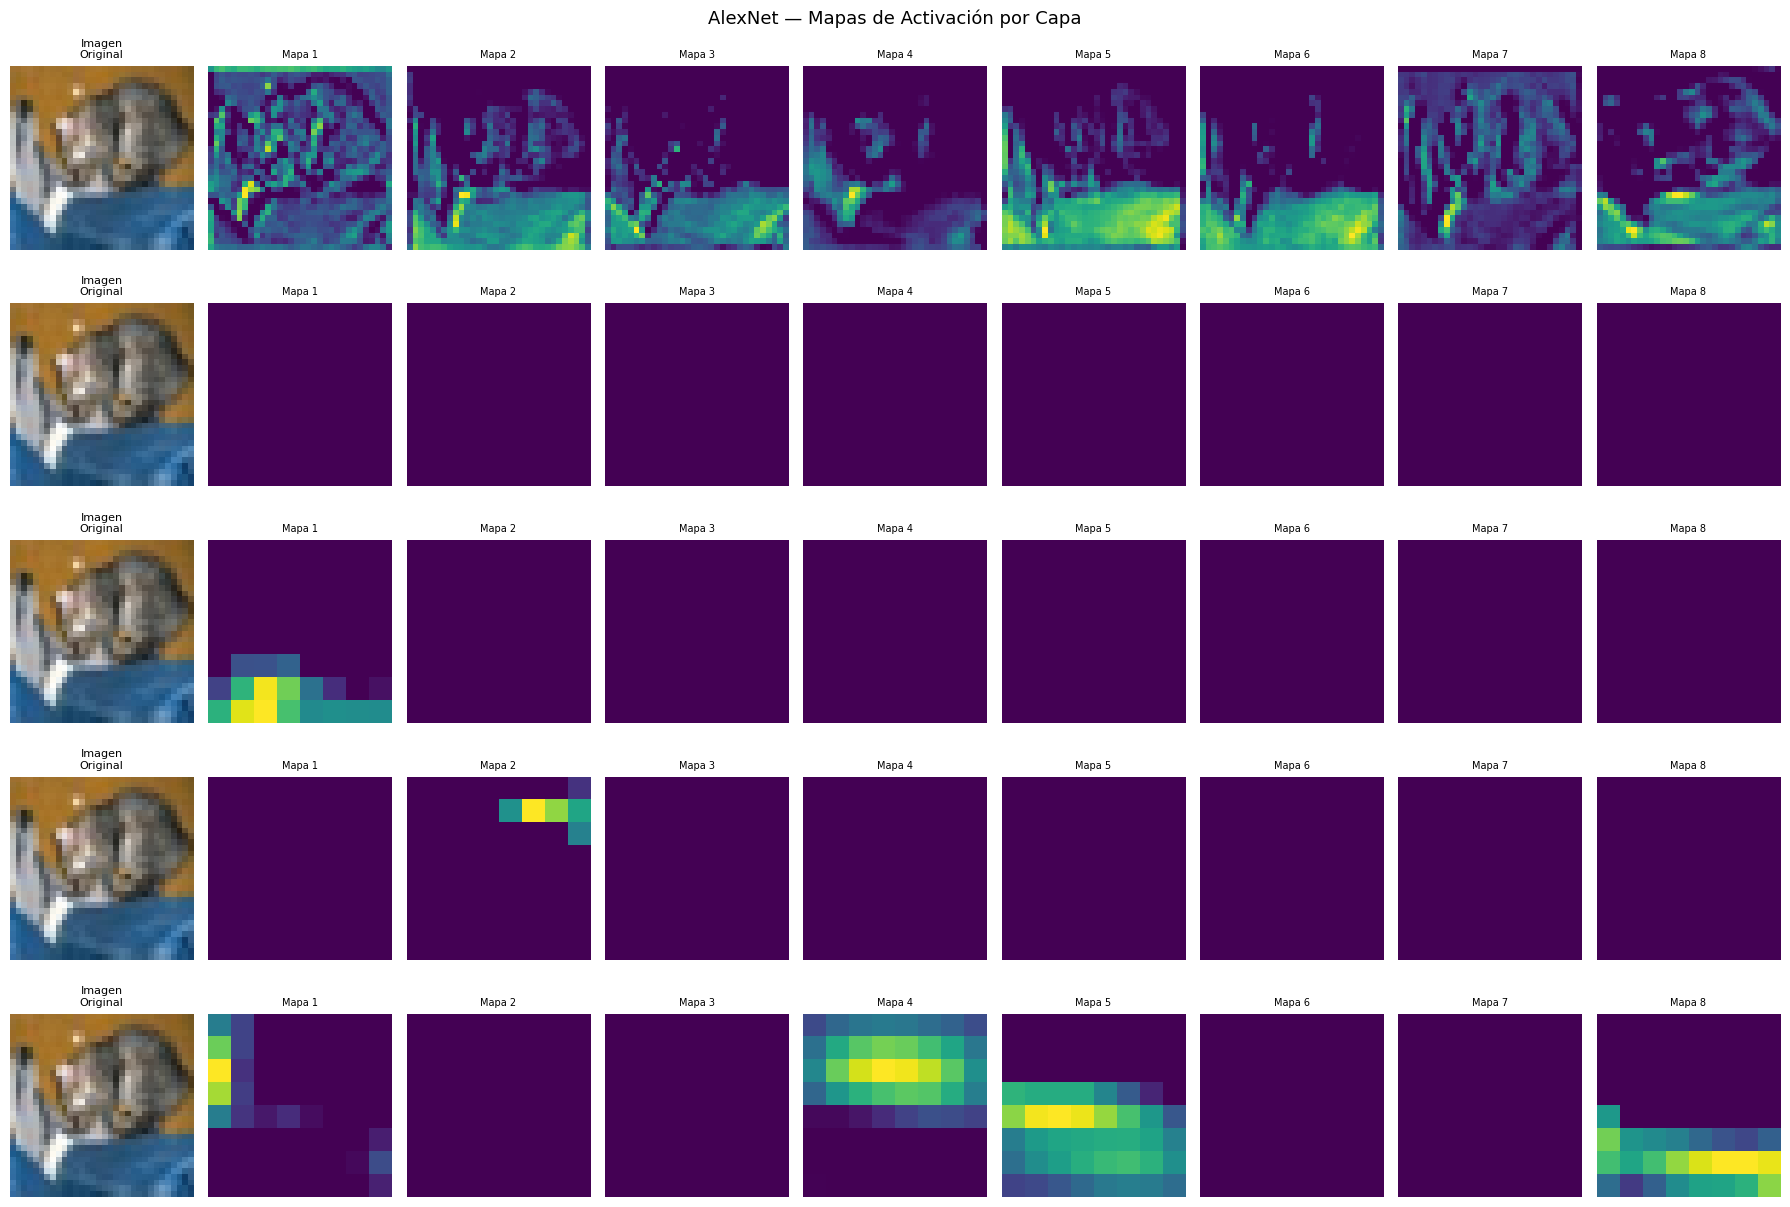

In [ ]:
def visualize_feature_maps(model, image_tensor, layer_indices=[0, 4, 8, 10, 12],
                            n_maps=8, title_prefix=''):
    """Visualiza mapas de activación de capas convolucionales seleccionadas."""
    activations = {}
    hooks = []

    def get_activation(name):
        def hook(module, input, output):
            activations[name] = output.detach()
        return hook

    # Registrar hooks en las capas Conv2d seleccionadas
    conv_count = 0
    for idx, layer in enumerate(model.features):
        if isinstance(layer, nn.Conv2d) and idx in layer_indices:
            hook = layer.register_forward_hook(get_activation(f'conv_idx{idx}'))
            hooks.append(hook)

    # Pasar la imagen por el modelo
    model.eval()
    with torch.no_grad():
        _ = model(image_tensor.unsqueeze(0).to(device))

    # Eliminar hooks
    for h in hooks:
        h.remove()

    if not activations:
        print('No se encontraron activaciones para los índices especificados.')
        return

    # Graficar mapas de activación
    n_layers = len(activations)
    fig, axes = plt.subplots(n_layers, n_maps + 1, figsize=(2 * (n_maps + 1), 2.5 * n_layers))
    if n_layers == 1:
        axes = axes[np.newaxis, :]

    # Mostrar imagen original en la primera columna de cada fila
    mean = np.array([0.4914, 0.4822, 0.4465])
    std  = np.array([0.2023, 0.1994, 0.2010])
    img_np = image_tensor.cpu().numpy().transpose(1, 2, 0)
    img_np = np.clip(std * img_np + mean, 0, 1)

    for row, (layer_name, activation) in enumerate(activations.items()):
        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title('Imagen\nOriginal', fontsize=8)
        axes[row, 0].axis('off')

        fmaps = activation[0]  # (C, H, W)
        for col in range(1, n_maps + 1):
            if col - 1 < fmaps.shape[0]:
                fmap = fmaps[col - 1].cpu().numpy()
                axes[row, col].imshow(fmap, cmap='viridis')
                axes[row, col].set_title(f'Mapa {col}', fontsize=7)
            axes[row, col].axis('off')

        axes[row, 0].set_ylabel(layer_name, fontsize=9, rotation=0, labelpad=60)

    fig.suptitle(f'{title_prefix}Mapas de Activación por Capa', fontsize=13)
    plt.tight_layout()
    plt.show()


# Seleccionar una imagen de muestra del conjunto de prueba
sample_img, sample_label = test_subset[0]
print(f'Clase de la imagen de muestra: {classes[sample_label]}')

# Visualizar mapas de activación del modelo AlexNet entrenado
visualize_feature_maps(
    model_alexnet, sample_img,
    layer_indices=[0, 4, 8, 10, 12],
    n_maps=8,
    title_prefix='AlexNet — '
)

### 5.3 Discusión sobre lo que Aprende Cada Capa

Analizando los mapas de activación observamos:

| Capa | Lo que aprende |
|------|---------------|
| **Conv1** | Detectores de bordes en distintas orientaciones (0°, 45°, 90°, 135°), gradientes de color y manchas de color. Los filtros son muy similares a los filtros de Gabor usados en visión clásica. |
| **Conv2** | Combinaciones de bordes: esquinas, líneas curvas, texturas simples. Los mapas ya muestran cierta selectividad hacia partes de objetos. |
| **Conv3-4** | Texturas más complejas, partes de objetos (ruedas, alas, patas). La respuesta es más selectiva y abstracta. |
| **Conv5** | Representaciones de alto nivel: formas completas o partes semánticamente significativas. Los mapas son más pequeños pero más informativos sobre la clase. |

**Observación clave**: En las primeras capas, los mapas de activación son grandes y granulares (muchos detalles de bajo nivel). En las capas profundas, los mapas son pequeños pero capturan información semántica de alto nivel. Esto refleja la jerarquía de representaciones que aprenden las redes convolucionales profundas.

---
## Sección 6: Ejemplo 4 — Comparación con Arquitecturas Más Simples

Para apreciar el poder de AlexNet, la comparamos con dos arquitecturas más simples:
- **MLP (Perceptrón Multicapa)**: Red completamente conectada sin capas convolucionales.
- **CNN Simple**: Red convolucional con solo 2 capas convolucionales.

### 6.1 Definición de Arquitecturas Simples

In [ ]:
class SimpleMLP(nn.Module):
    """Perceptrón multicapa simple para clasificación de imágenes CIFAR-10."""
    def __init__(self, num_classes=10):
        super(SimpleMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),                      # Aplanar la imagen: 32*32*3 = 3072
            nn.Linear(32 * 32 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)


class SimpleCNN(nn.Module):
    """CNN simple con 2 capas convolucionales para clasificación de imágenes CIFAR-10."""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                # 32x32 -> 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                # 16x16 -> 8x8
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        return self.fc_layers(x)


# Instanciar los modelos y comparar número de parámetros
mlp     = SimpleMLP(num_classes=10).to(device)
cnn     = SimpleCNN(num_classes=10).to(device)
alexnet_scratch = AlexNet(num_classes=10).to(device)

print(f'Parámetros — MLP simple   : {count_parameters(mlp):>12,}')
print(f'Parámetros — CNN simple   : {count_parameters(cnn):>12,}')
print(f'Parámetros — AlexNet      : {count_parameters(alexnet_scratch):>12,}')

Parámetros — MLP simple   :    1,640,330
Parámetros — CNN simple   :      545,098
Parámetros — AlexNet      :    3,831,114


### 6.2 Entrenamiento de los Tres Modelos

In [ ]:
# Entrenar MLP
optimizer_mlp = optim.Adam(mlp.parameters(), lr=1e-3)
print('=== Entrenamiento del MLP Simple ===')
history_mlp, time_mlp = train_model(
    mlp, train_loader, val_loader, criterion, optimizer_mlp, NUM_EPOCHS, device
)

print()

# Entrenar CNN simple
optimizer_cnn = optim.Adam(cnn.parameters(), lr=1e-3)
print('=== Entrenamiento de la CNN Simple ===')
history_cnn, time_cnn = train_model(
    cnn, train_loader, val_loader, criterion, optimizer_cnn, NUM_EPOCHS, device
)

print()

# Entrenar AlexNet (reutilizar el modelo ya entrenado anteriormente)
print('=== (AlexNet ya entrenada en la Sección 3) ===')
print(f'Exactitud de validación final de AlexNet: {history_alexnet["val_acc"][-1]:.2f}%')

=== Entrenamiento del MLP Simple ===
Época [ 1/5] | Pérdida Entren: 2.0437 | Exactitud Entren: 25.84% | Pérdida Val: 1.9347 | Exactitud Val: 27.50%
Época [ 2/5] | Pérdida Entren: 1.8847 | Exactitud Entren: 31.06% | Pérdida Val: 1.8836 | Exactitud Val: 32.00%
Época [ 3/5] | Pérdida Entren: 1.8326 | Exactitud Entren: 33.34% | Pérdida Val: 1.8897 | Exactitud Val: 32.80%
Época [ 4/5] | Pérdida Entren: 1.7865 | Exactitud Entren: 34.92% | Pérdida Val: 1.7981 | Exactitud Val: 35.70%
Época [ 5/5] | Pérdida Entren: 1.7730 | Exactitud Entren: 36.12% | Pérdida Val: 1.8240 | Exactitud Val: 33.20%

Tiempo total de entrenamiento: 19.6s

=== Entrenamiento de la CNN Simple ===
Época [ 1/5] | Pérdida Entren: 1.9756 | Exactitud Entren: 27.50% | Pérdida Val: 1.8547 | Exactitud Val: 31.20%
Época [ 2/5] | Pérdida Entren: 1.7000 | Exactitud Entren: 38.60% | Pérdida Val: 1.6758 | Exactitud Val: 38.00%
Época [ 3/5] | Pérdida Entren: 1.5741 | Exactitud Entren: 43.22% | Pérdida Val: 1.5455 | Exactitud Val: 44.6

### 6.3 Tabla Comparativa de Resultados

In [ ]:
# Evaluar todos los modelos en el conjunto de prueba
_, test_acc_mlp = evaluate(mlp,           test_loader, criterion, device)
_, test_acc_cnn = evaluate(cnn,           test_loader, criterion, device)
_, test_acc_alex = evaluate(model_alexnet, test_loader, criterion, device)

# Tabla de comparación
print('\n' + '='*75)
print(f'{"Modelo":<20} {"Parámetros":>14} {"Exactitud Test":>16} {"Tiempo (s)":>12}')
print('='*75)
print(f'{"MLP Simple":<20} {count_parameters(mlp):>14,} {test_acc_mlp:>15.2f}% {time_mlp:>11.1f}s')
print(f'{"CNN Simple":<20} {count_parameters(cnn):>14,} {test_acc_cnn:>15.2f}% {time_cnn:>11.1f}s')
print(f'{"AlexNet":<20} {count_parameters(model_alexnet):>14,} {test_acc_alex:>15.2f}% {time_alexnet:>11.1f}s')
print('='*75)


Modelo                   Parámetros   Exactitud Test   Tiempo (s)
MLP Simple                1,640,330           37.20%        19.6s
CNN Simple                  545,098           51.60%        47.1s
AlexNet                   3,831,114           30.90%       811.0s


### 6.4 Visualización Comparativa de las Curvas de Aprendizaje

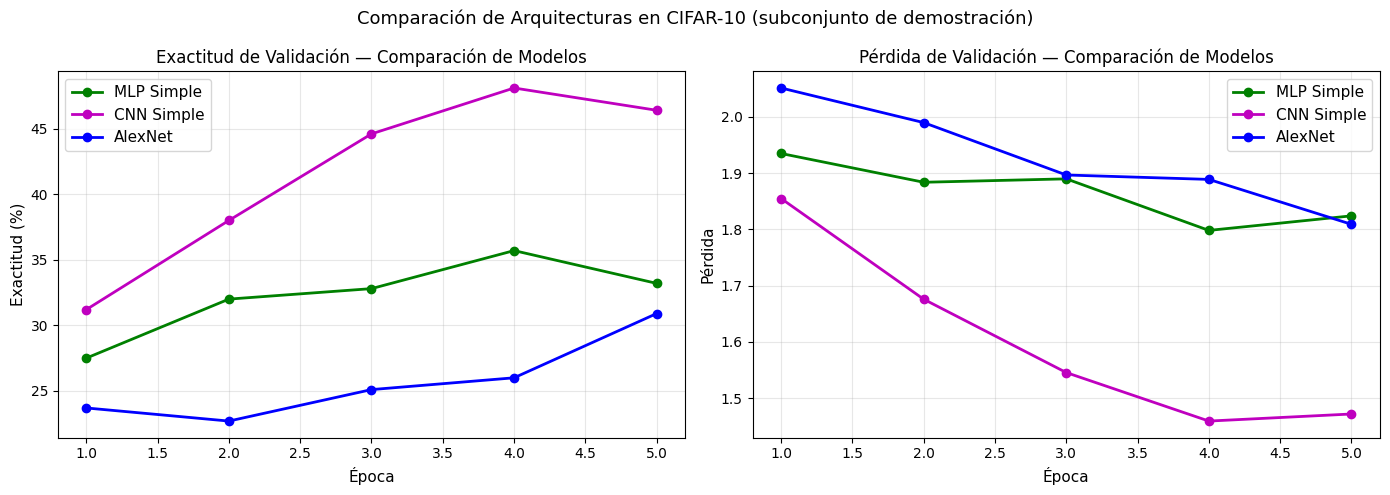

In [ ]:
# Comparar curvas de exactitud de validación de los tres modelos
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Exactitud de validación
ax1.plot(epochs, history_mlp['val_acc'],     'g-o', label='MLP Simple',  linewidth=2)
ax1.plot(epochs, history_cnn['val_acc'],     'm-o', label='CNN Simple',  linewidth=2)
ax1.plot(epochs, history_alexnet['val_acc'], 'b-o', label='AlexNet',     linewidth=2)
ax1.set_title('Exactitud de Validación — Comparación de Modelos', fontsize=12)
ax1.set_xlabel('Época', fontsize=11)
ax1.set_ylabel('Exactitud (%)', fontsize=11)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Pérdida de validación
ax2.plot(epochs, history_mlp['val_loss'],     'g-o', label='MLP Simple',  linewidth=2)
ax2.plot(epochs, history_cnn['val_loss'],     'm-o', label='CNN Simple',  linewidth=2)
ax2.plot(epochs, history_alexnet['val_loss'], 'b-o', label='AlexNet',     linewidth=2)
ax2.set_title('Pérdida de Validación — Comparación de Modelos', fontsize=12)
ax2.set_xlabel('Época', fontsize=11)
ax2.set_ylabel('Pérdida', fontsize=11)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle('Comparación de Arquitecturas en CIFAR-10 (subconjunto de demostración)',
             fontsize=13)
plt.tight_layout()
plt.show()

### 6.5 Gráfico de Barras: Exactitud vs. Número de Parámetros

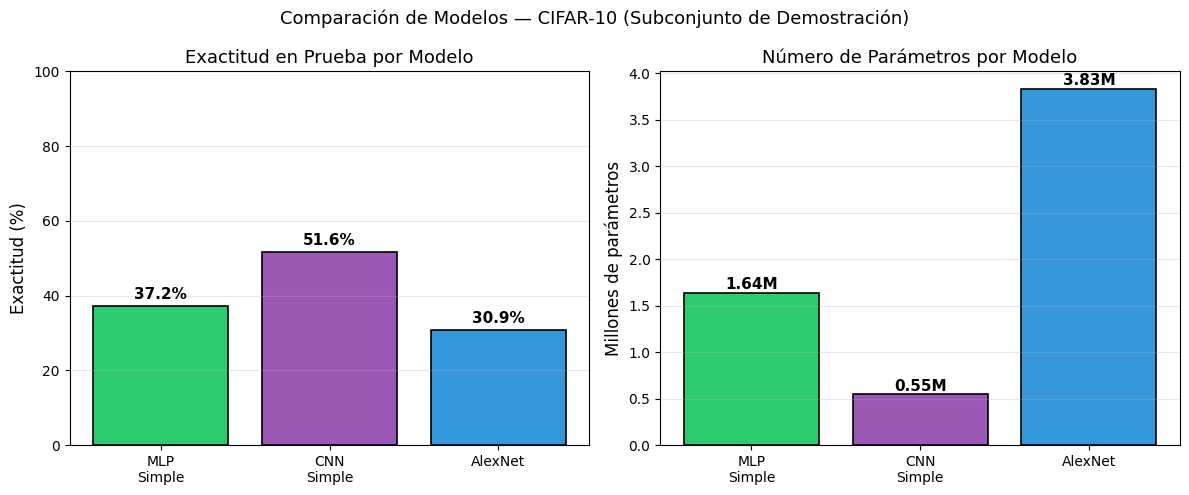

In [ ]:
# Gráfico de barras para comparación visual
model_names = ['MLP\nSimple', 'CNN\nSimple', 'AlexNet']
accuracies  = [test_acc_mlp, test_acc_cnn, test_acc_alex]
params      = [count_parameters(mlp) / 1e6,
               count_parameters(cnn) / 1e6,
               count_parameters(model_alexnet) / 1e6]
colors      = ['#2ecc71', '#9b59b6', '#3498db']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Exactitud en prueba
bars1 = ax1.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.2)
ax1.set_title('Exactitud en Prueba por Modelo', fontsize=13)
ax1.set_ylabel('Exactitud (%)', fontsize=12)
ax1.set_ylim(0, 100)
ax1.grid(True, axis='y', alpha=0.3)
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Número de parámetros (en millones)
bars2 = ax2.bar(model_names, params, color=colors, edgecolor='black', linewidth=1.2)
ax2.set_title('Número de Parámetros por Modelo', fontsize=13)
ax2.set_ylabel('Millones de parámetros', fontsize=12)
ax2.grid(True, axis='y', alpha=0.3)
for bar, p in zip(bars2, params):
    ax2.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01,
             f'{p:.2f}M', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Comparación de Modelos — CIFAR-10 (Subconjunto de Demostración)', fontsize=13)
plt.tight_layout()
plt.show()

### 6.6 Análisis de Resultados

A partir de los experimentos realizados con el subconjunto de demostración (5,000 imágenes de entrenamiento, 5 épocas), se pueden extraer las siguientes conclusiones:

**MLP Simple**:
- Trata la imagen como un vector plano, ignorando la estructura espacial 2D.
- No es invariante a traslaciones ni rotaciones pequeñas.
- Menor número de parámetros en las capas ocultas, pero la primera capa densa tiene muchas conexiones (32×32×3 → 512).
- Generalmente el de peor rendimiento para imágenes.

**CNN Simple**:
- Las capas convolucionales capturan estructura espacial local.
- Mejor rendimiento que el MLP con menos parámetros en las capas convolucionales.
- Sin técnicas de regularización, puede sobreajustar.

**AlexNet**:
- Arquitectura más profunda con más capacidad representacional.
- Usa Dropout para regularización, lo que mejora la generalización.
- LRN y Max Pooling con solapamiento mejoran la robustez.
- Generalmente obtiene el mejor rendimiento, especialmente con más datos y épocas de entrenamiento.

**Conclusión general**: La arquitectura más profunda (AlexNet) tiende a superar a las más simples cuando se tienen suficientes datos y capacidad computacional. Sin embargo, el trade-off entre complejidad del modelo y datos disponibles es clave en la práctica.

---
## Sección 7: Referencias Bibliográficas

### Artículos Científicos Fundamentales

1. **Krizhevsky, A., Sutskever, I., & Hinton, G. E.** (2012). *ImageNet Classification with Deep Convolutional Neural Networks.* Advances in Neural Information Processing Systems (NeurIPS), 25, 1097–1105. [https://papers.nips.cc/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html](https://papers.nips.cc/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html)

2. **Russakovsky, O., Deng, J., Su, H., Krause, J., Satheesh, S., Ma, S., ... & Fei-Fei, L.** (2015). *ImageNet Large Scale Visual Recognition Challenge.* International Journal of Computer Vision (IJCV), 115(3), 211–252. [https://doi.org/10.1007/s11263-015-0816-y](https://doi.org/10.1007/s11263-015-0816-y)

3. **Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R.** (2014). *Dropout: A Simple Way to Prevent Neural Networks from Overfitting.* Journal of Machine Learning Research (JMLR), 15(56), 1929–1958. [https://jmlr.org/papers/v15/srivastava14a.html](https://jmlr.org/papers/v15/srivastava14a.html)

4. **LeCun, Y., Bengio, Y., & Hinton, G.** (2015). *Deep Learning.* Nature, 521(7553), 436–444. [https://doi.org/10.1038/nature14539](https://doi.org/10.1038/nature14539)

5. **Simonyan, K., & Zisserman, A.** (2014). *Very Deep Convolutional Networks for Large-Scale Image Recognition.* arXiv:1409.1556. [https://arxiv.org/abs/1409.1556](https://arxiv.org/abs/1409.1556)

6. **He, K., Zhang, X., Ren, S., & Sun, J.** (2016). *Deep Residual Learning for Image Recognition.* IEEE CVPR, 770–778. [https://doi.org/10.1109/CVPR.2016.90](https://doi.org/10.1109/CVPR.2016.90)

### Libros de Referencia

7. **Goodfellow, I., Bengio, Y., & Courville, A.** (2016). *Deep Learning.* MIT Press. Capítulo 9: Convolutional Networks. [https://www.deeplearningbook.org/](https://www.deeplearningbook.org/)

8. **Géron, A.** (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (2nd ed.). O'Reilly Media.

### Recursos en Línea

9. **Documentación oficial de PyTorch**: [https://pytorch.org/docs/stable/index.html](https://pytorch.org/docs/stable/index.html)
   - Módulo `torch.nn`: [https://pytorch.org/docs/stable/nn.html](https://pytorch.org/docs/stable/nn.html)
   - `torchvision.models`: [https://pytorch.org/vision/stable/models.html](https://pytorch.org/vision/stable/models.html)

10. **CS231n: Convolutional Neural Networks for Visual Recognition** (Stanford University): [http://cs231n.stanford.edu/](http://cs231n.stanford.edu/)

11. **PyTorch Transfer Learning Tutorial**: [https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)

12. **Visualización de CNNs** — Zeiler, M. D., & Fergus, R. (2014). *Visualizing and Understanding Convolutional Networks.* ECCV. [https://arxiv.org/abs/1311.2901](https://arxiv.org/abs/1311.2901)

13. **CIFAR-10 Dataset** — Krizhevsky, A. (2009). *Learning Multiple Layers of Features from Tiny Images.* Technical Report. [https://www.cs.toronto.edu/~kriz/cifar.html](https://www.cs.toronto.edu/~kriz/cifar.html)